# Taller — Conversión y Manipulación de Espacios de Color

---

## Instalación de dependencias

In [74]:
import subprocess, sys
pkgs = ["opencv-python", "scikit-image", "numpy", "matplotlib", "colormath", "scikit-learn", "Pillow", "pandas"]
for p in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])

---

## Importación de ciertos modulos o librerias enteras en su defecto

In [75]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
from skimage import exposure, color as skcolor
from sklearn.cluster import KMeans


---

## 1) Conversion espacios de color

### Funcion auxiliar para mostrar la(s) imagen(es)

In [93]:
def show_images(images, formats, cmap_list=None):

    n = len(images)

    fig, axes = plt.subplots(1, n, figsize=(17, 3))
    if n == 1: axes = [axes]

    for i in range(n):
        axes[i].imshow(images[i], cmap=cmap_list[i] if cmap_list else 'gray')
        axes[i].set_title("Formato " + formats[i], fontsize=9, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

### Imagen original cargada

In [94]:
IMAGE_PATH = "peppers.png"
image = cv2.imread(IMAGE_PATH)

### Imagen RGB

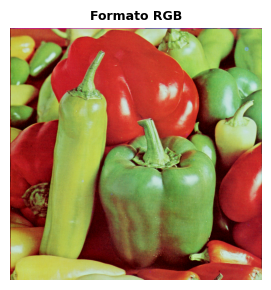

In [95]:
#Se carga como BGR y despues RGB

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
show_images([image_rgb], ["RGB"])

### Otras conversiones y sus visualizaciones respectivas

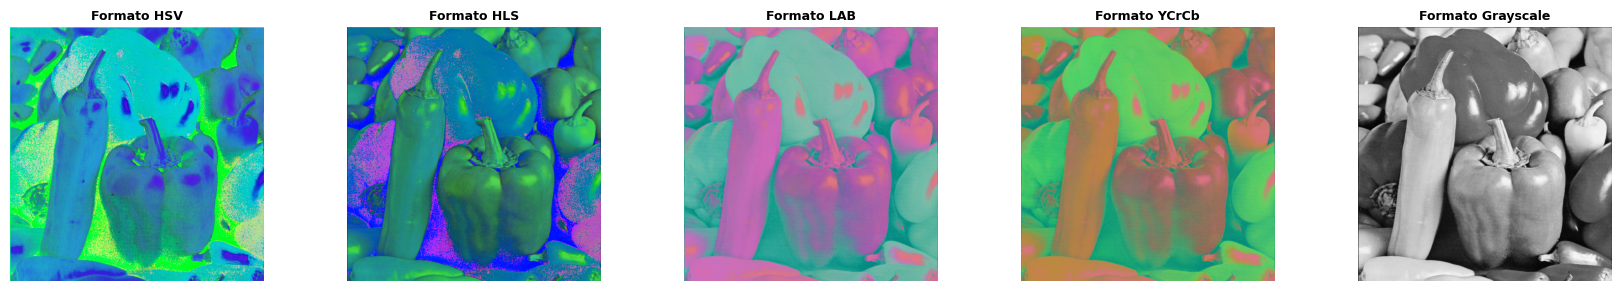

In [96]:
image_hsv   = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
image_hls   = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HLS)
image_lab   = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
image_ycrcb = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2YCrCb)
image_gray  = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

show_images([image_hsv, image_hls, image_lab, image_ycrcb, image_gray], 
            ["HSV", "HLS", "LAB", "YCrCb", "Grayscale"],
            cmap_list=[None, None, None, None, 'gray'])

### Tabla de rango de valores

In [92]:
rangos = [
    ("RGB",   "R, G, B", "R (Rojo) G (Verde) B (Azul)", "[0, 255] cada canal"),
    ("HSV",   "H, S, V", "H (Matiz) S (Saturación) V (Valor)", "H:[0,180]  S:[0,255]  V:[0,255]"),
    ("HLS",   "H, L, S", "H (Matiz) L (Luminosidad) S (Saturación)", "H:[0,180]  L:[0,255]  S:[0,255]"),
    ("LAB",   "L*, a*, b*", "L (Luminancia) A (verde↔rojo) B (azul↔amarillo)", "L:[0,255]  a:[0,255]  b:[0,255] (desplazado)"),
    ("YCrCb", "Y, Cr, Cb", "Y (Luma) Cr (Rojo-dif.) Cb (Azul-dif.)", "[0, 255] cada canal"),
    ("Gray",  "Intensidad", "Intensidad", "[0, 255]"),
]

df = pd.DataFrame(rangos, columns=["Espacio", "Canales", "Significado", "Rango"])
df


,Espacio,Canales,Significado,Rango
0,RGB,"R, G, B",R (Rojo) G (Verde) B (Azul),"[0, 255] cada canal"
1,HSV,"H, S, V",H (Matiz) S (Saturación) V (Valor),"H:[0,180] S:[0,255] V:[0,255]"
2,HLS,"H, L, S",H (Matiz) L (Luminosidad) S (Saturación),"H:[0,180] L:[0,255] S:[0,255]"
3,LAB,"L*, a*, b*",L (Luminancia) A (verde↔rojo) B (azul↔amarillo),"L:[0,255] a:[0,255] b:[0,255] (desplazado)"
4,YCrCb,"Y, Cr, Cb",Y (Luma) Cr (Rojo-dif.) Cb (Azul-dif.),"[0, 255] cada canal"
5,Gray,Intensidad,Intensidad,"[0, 255]"


*LAB en OpenCV escala L*[0..100]→[0..255], a*/b* se desplazan 128"*

---

## 2) Visualización 3D de espacios de color

Se grafican los píxeles de la imagen en el cubo **RGB** y el cilindro **HSV**.

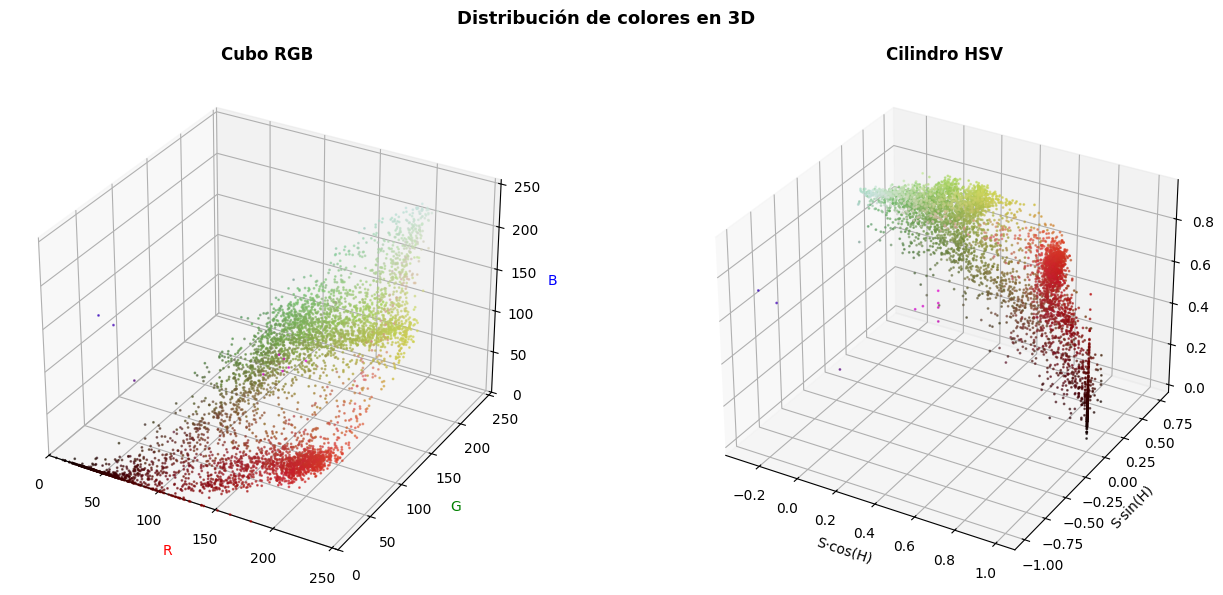

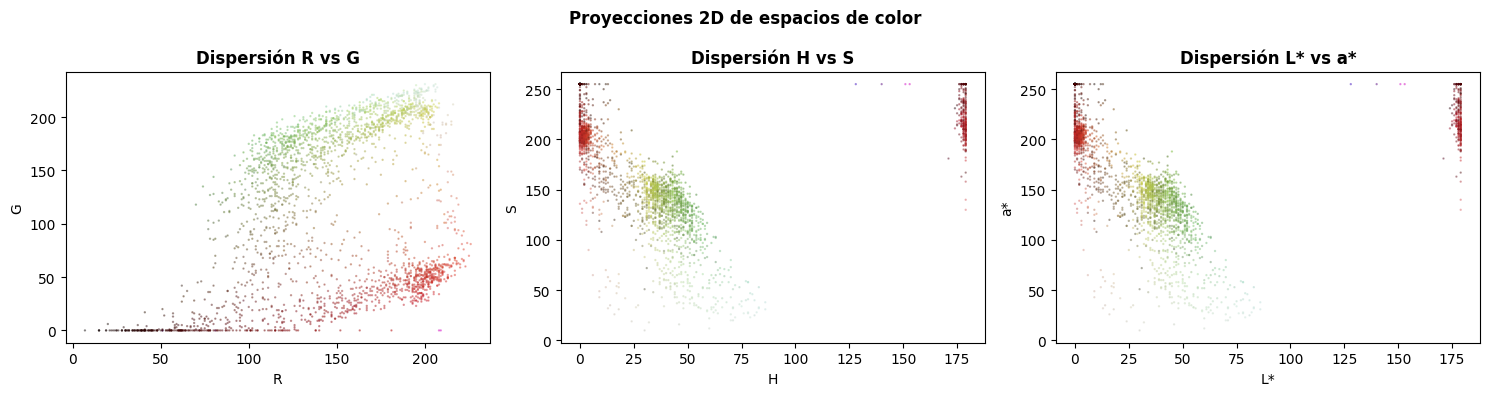

In [97]:
step  = max(1, image_rgb.shape[0] * image_rgb.shape[1] // 5000)
pixel = image_rgb.reshape(-1, 3)[::step]
colores = pixel / 255.0  

# Cubo RGB
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(pixel[:, 0], pixel[:, 1], pixel[:, 2],
            c=colores, s=1, alpha=0.6)
ax1.set_xlabel('R', color='red');  ax1.set_ylabel('G', color='green')
ax1.set_zlabel('B', color='blue'); ax1.set_title('Cubo RGB', fontweight='bold')
ax1.set_xlim(0, 255); ax1.set_ylim(0, 255); ax1.set_zlim(0, 255)

# Cilindro HSV 
img_hsv_raw = cv2.cvtColor(cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2HSV)
hsv_pixels  = img_hsv_raw.reshape(-1, 3)[::step].astype(float)
H = hsv_pixels[:, 0] / 180 * 2 * np.pi  
S = hsv_pixels[:, 1] / 255.0             
V = hsv_pixels[:, 2] / 255.0            
X_cil = S * np.cos(H)
Y_cil = S * np.sin(H)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_cil, Y_cil, V, c=colores, s=1, alpha=0.6)
ax2.set_xlabel('S·cos(H)'); ax2.set_ylabel('S·sin(H)')
ax2.set_zlabel('V'); ax2.set_title('Cilindro HSV', fontweight='bold')

plt.suptitle("Distribución de colores en 3D", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Comparación de distribuciones 2D ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pares = [("R", "G", 0, 1), ("H", "S", 0, 1), ("L*", "a*", 0, 1)]
datos_espacios = [pixel, hsv_pixels]

for i, (xl, yl, ci, cj) in enumerate(pares):
    d = pixel if i == 0 else hsv_pixels
    axes[i].scatter(d[::2, ci], d[::2, cj], c=colores[::2], s=0.5, alpha=0.4)
    axes[i].set_xlabel(xl); axes[i].set_ylabel(yl)
    axes[i].set_title(f"Dispersión {xl} vs {yl}", fontweight='bold')

plt.suptitle("Proyecciones 2D de espacios de color", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
